<a href="https://colab.research.google.com/github/ronith-raj/SYNTECXHUB/blob/main/task_2%20(project_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SuperStoreOrders.csv to SuperStoreOrders.csv/SuperStoreOrders.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [ ]:
df = pd.read_csv("SuperStoreOrders.csv/SuperStoreOrders.csv", encoding='latin1')

df.head()

,ï»¿order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
# Convert Order Date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

# Check null values
print(df.isnull().sum())

# Basic info
df.info()

ï»¿order_id       0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ï»¿order_id     51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  objec

In [ ]:
print(df.columns)

Index(['ï»¿order_id', 'ship_date', 'ship_mode', 'customer_name', 'segment',
       'state', 'country', 'market', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print(df.columns)

Index(['ï»¿order_id', 'ship_date', 'ship_mode', 'customer_name', 'segment',
       'state', 'country', 'market', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')


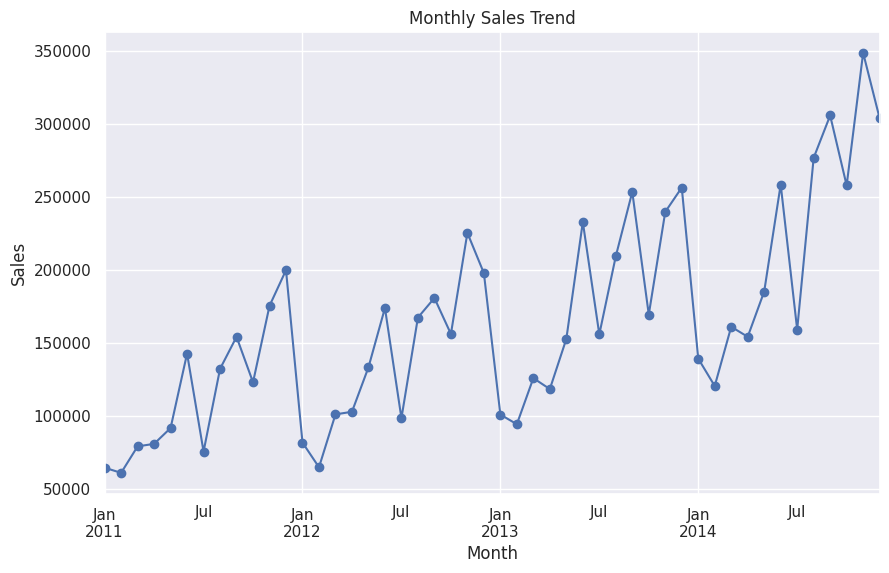

In [ ]:
# Clean column names (applies to existing columns)
df.columns = df.columns.str.strip().str.lower()

# Convert 'sales' column to numeric, as it might be of object type
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# 'order_date' is already the datetime index, so no need to convert or set index again.
# Removed: df['order date'] = pd.to_datetime(df['order date'])
# Removed: df.set_index('order date', inplace=True)

# Monthly sales - 'resample' uses the DataFrame's existing datetime index
monthly_sales = df['sales'].resample('ME').sum()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Added figsize for better visualization
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True) # Added grid for readability

plt.savefig("monthly_sales.png") # Added to save the plot
plt.show()

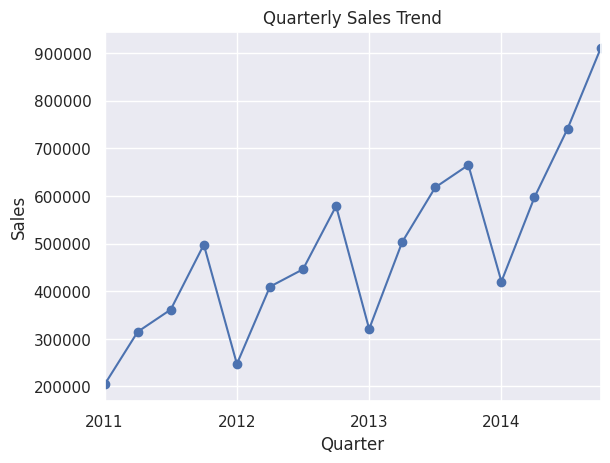

In [ ]:
quarterly_sales = df['sales'].resample('QE').sum()

plt.figure()
quarterly_sales.plot(marker='o')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.savefig("quarterly_sales.png")
plt.show()

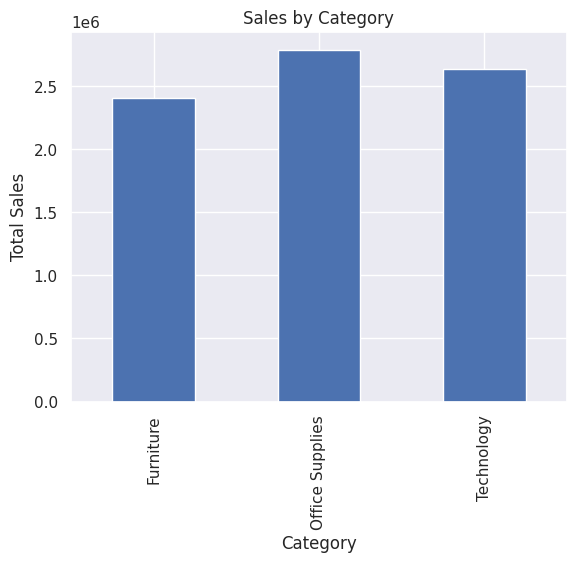

In [ ]:
category_sales = df.groupby('category')['sales'].sum()

plt.figure()
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("category_bar.png")
plt.show()

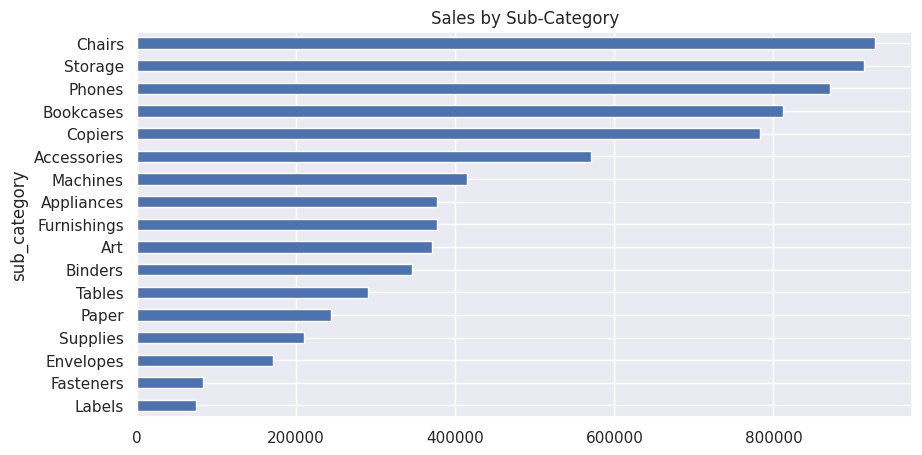

In [ ]:
sub_category_sales = df.groupby('sub_category')['sales'].sum().sort_values()

plt.figure(figsize=(10,5))
sub_category_sales.plot(kind='barh')

plt.title("Sales by Sub-Category")

plt.savefig("subcategory_bar.png")
plt.show()

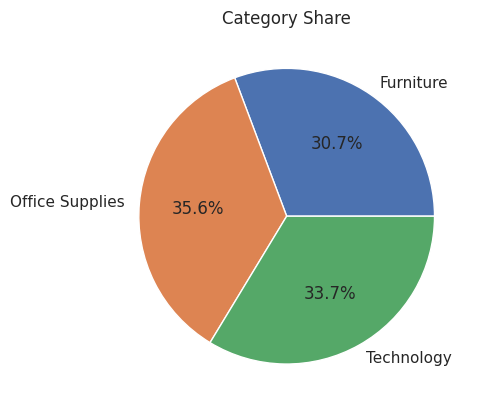

In [ ]:
plt.figure()
category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Category Share")
plt.ylabel("")

plt.savefig("category_pie.png")
plt.show()

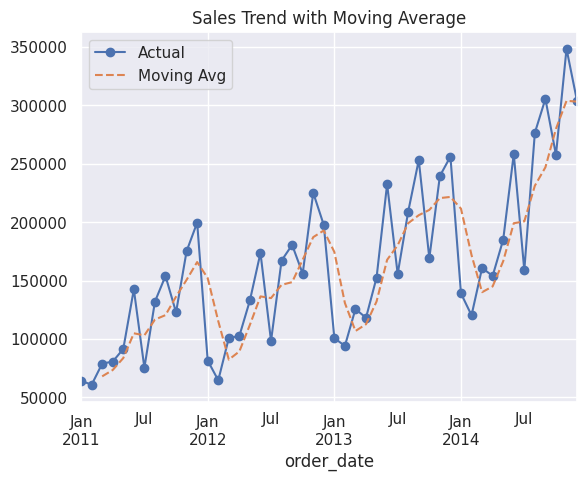

In [ ]:
monthly_ma = monthly_sales.rolling(window=3).mean()

plt.figure()
monthly_sales.plot(label="Actual", marker='o')
monthly_ma.plot(label="Moving Avg", linestyle='--')

plt.legend()
plt.title("Sales Trend with Moving Average")

plt.savefig("moving_avg.png")
plt.show()

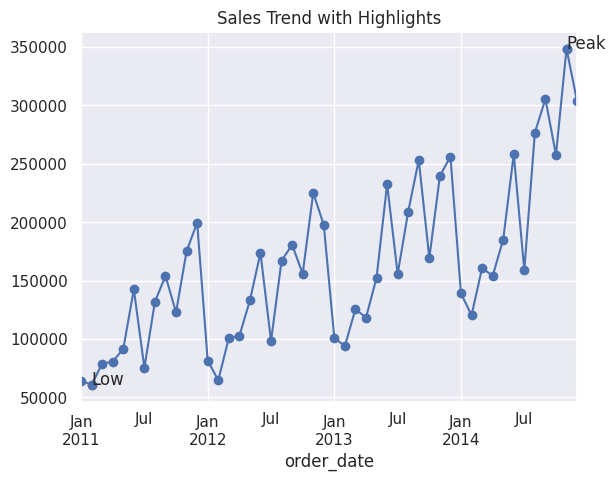

In [ ]:
plt.figure()
monthly_sales.plot(marker='o')

max_point = monthly_sales.idxmax()
min_point = monthly_sales.idxmin()

plt.scatter(max_point, monthly_sales.max())
plt.scatter(min_point, monthly_sales.min())

plt.text(max_point, monthly_sales.max(), "Peak")
plt.text(min_point, monthly_sales.min(), "Low")

plt.title("Sales Trend with Highlights")

plt.savefig("highlight.png")
plt.show()

In [ ]:
summary = f"""
SUMMARY REPORT

Total Sales: {df['sales'].sum():.2f}

Top Category: {category_sales.idxmax()}

Top Sub-Category: {sub_category_sales.idxmax()}

Best Month: {monthly_sales.idxmax().strftime('%B %Y')}

Insights:
- Sales show seasonal trends across months
- Technology/Furniture/Office Supplies dominate (based on data)
- Certain sub-categories contribute more revenue
"""

print(summary)

with open("summary.txt", "w") as f:
    f.write(summary)


SUMMARY REPORT

Total Sales: 7835128.00

Top Category: Office Supplies

Top Sub-Category: Chairs

Best Month: November 2014

Insights:
- Sales show seasonal trends across months
- Technology/Furniture/Office Supplies dominate (based on data)
- Certain sub-categories contribute more revenue



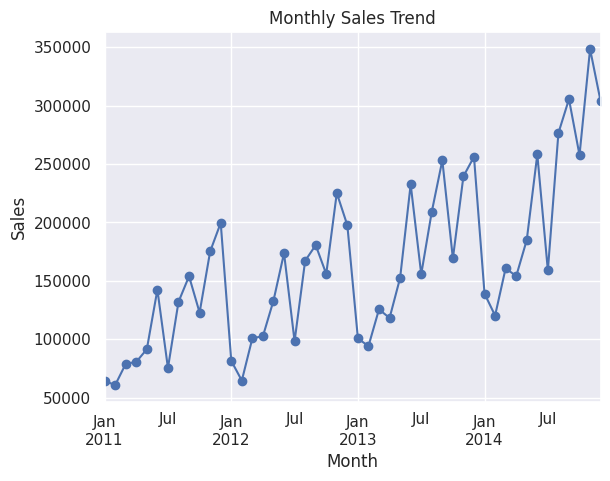

In [ ]:
plt.figure()
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("monthly_sales.png")   # ✅ IMPORTANT
plt.show()

In [ ]:
import os
print(os.listdir())

['.config', 'summary.txt', 'subcategory_bar.png', 'moving_avg.png', 'SuperStoreOrders.csv', 'quarterly_sales.png', 'category_bar.png', 'category_pie.png', 'monthly_sales.png', 'highlight.png', 'sample_data']


In [ ]:
from google.colab import files

files.download("monthly_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>